# ConfigProbe — ML & DL Analysis

Applies machine learning and deep learning to uncover non-obvious patterns in the config dataset:
- **What predicts availability?** (supervised classification)
- **What predicts whether an exit is a datacenter?** (supervised classification)
- **Can we predict latency from config metadata?** (regression)
- **Do configs naturally cluster into meaningful groups?** (unsupervised clustering)
- **Anomaly detection** — which working configs look unusual?
- **Protocol × Geography interaction** — datacenter rate heatmap

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
from matplotlib.backends.backend_pdf import PdfPages

try:
    import cuml
    cuml.set_global_output_type('numpy')
    from cuml.ensemble import RandomForestClassifier, IsolationForest
    from cuml.linear_model import LogisticRegression
    from cuml.cluster import KMeans
    from cuml.decomposition import PCA
    from cuml.manifold import TSNE
    from cuml.preprocessing import StandardScaler
    USE_GPU = True
except ImportError:
    from sklearn.ensemble import RandomForestClassifier, IsolationForest
    from sklearn.linear_model import LogisticRegression
    from sklearn.cluster import KMeans
    from sklearn.decomposition import PCA
    from sklearn.manifold import TSNE
    from sklearn.preprocessing import StandardScaler
    USE_GPU = False

from sklearn.ensemble import GradientBoostingClassifier, GradientBoostingRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import cross_val_score, StratifiedKFold, train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, silhouette_score
from sklearn.pipeline import Pipeline

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (12, 5)

results_dir = Path('../results/merged')
csv_files = sorted(results_dir.rglob('results.csv'))
assert csv_files, f'No results.csv found under {results_dir}'
CSV_PATH = csv_files[-1]
print(f'Loading: {CSV_PATH}')
print(f'ML backend: {"GPU — RAPIDS cuML" if USE_GPU else "CPU — scikit-learn"}')

pdf = PdfPages('ml_report.pdf')
print('PDF report will be saved to: ml_report.pdf')


def _save_text_page(pdf, content, title='', fontsize=8.5):
    """Render a text/table summary as a full PDF page."""
    if not isinstance(content, str):
        content = str(content)
    n_lines = content.count('\n') + 1
    if n_lines > 50:
        fontsize = 6.5
    elif n_lines > 35:
        fontsize = 7.5
    fig = plt.figure(figsize=(11, 8.5))
    fig.patch.set_facecolor('white')
    if title:
        fig.text(0.04, 0.97, title, fontsize=13, fontweight='bold', va='top', color='#1A237E')
        fig.text(0.04, 0.91, content, fontsize=fontsize, va='top',
                 family='monospace', color='#212121', linespacing=1.4)
    else:
        fig.text(0.04, 0.97, content, fontsize=fontsize, va='top',
                 family='monospace', color='#212121', linespacing=1.4)
    pdf.savefig(fig, bbox_inches='tight')
    plt.close(fig)

Loading: ../results/merged/results.csv
ML backend: CPU — scikit-learn
PDF report will be saved to: ml_report.pdf


In [2]:

# Save every plot as a PNG in ml_analysis_plots/ alongside this notebook
_plots_dir = Path('ml_analysis_plots')
import shutil
if _plots_dir.exists():
    shutil.rmtree(_plots_dir)
_plots_dir.mkdir()
_plot_counter = [0]

if getattr(plt.show, '_is_autosave', False):
    plt.show = plt.show._orig
_orig_plt_show = plt.show

def _autosave_show(*args, **kwargs):
    _plot_counter[0] += 1
    fig = plt.gcf()
    fig.savefig(_plots_dir / f'plot_{_plot_counter[0]:02d}.png', bbox_inches='tight', dpi=150)
    pdf.savefig(fig, bbox_inches='tight')
    _orig_plt_show(*args, **kwargs)

_autosave_show._is_autosave = True
_autosave_show._orig = _orig_plt_show
plt.show = _autosave_show
print(f'Plots will be auto-saved to: {_plots_dir.resolve()}')


Plots will be auto-saved to: /home/reza/pave/analysis/ml_analysis_plots


---
## 1. Data Preparation & Feature Engineering

In [3]:
df = pd.read_csv(CSV_PATH)

df['is_redirecting'] = df['is_redirecting'].fillna(False).astype(bool)
df['is_datacenter']  = df['is_datacenter'].fillna(False).astype(bool)
df['is_blacklisted'] = df['is_blacklisted'].fillna(False).astype(bool)

for col in ['proxy_detected', 'ipv6_leak', 'dns_leak']:
    if col in df.columns:
        df[col] = df[col].astype(str).str.lower().eq('true')
df['has_ipv6'] = df['ipv6_exit_ip'].notna() if 'ipv6_exit_ip' in df.columns else False

df['is_standard_port'] = df['port'].isin([80, 443, 8080, 8443, 1080, 1194]).astype(int)
df['port_log']         = np.log1p(df['port'])
df['latency_log']      = np.log1p(df['latency_ms'].fillna(0))

le_proto = LabelEncoder()
df['protocol_enc'] = le_proto.fit_transform(df['protocol'].fillna('unknown'))

country_freq_map = df['country'].fillna('Unknown').value_counts().to_dict()
df['country_freq'] = df['country'].fillna('Unknown').map(country_freq_map)

asn_freq_map = df['asn'].fillna('Unknown').value_counts().to_dict()
df['asn_freq'] = df['asn'].fillna('Unknown').map(asn_freq_map)

print(f'Dataset shape: {df.shape}')
print(f'Working configs : {df["is_redirecting"].sum():,} / {len(df):,}')
print(f'Datacenter exits: {df[df["is_redirecting"]]["is_datacenter"].sum():,}')
print(f'Unique ASNs     : {df["asn"].nunique()}')

wdf = df[df['is_redirecting']]
print(f'\nSecurity check coverage (working configs only):')
print(f'  proxy_detected : {int(wdf["proxy_detected"].sum())} / {len(wdf)}')
print(f'  has_ipv6       : {int(wdf["has_ipv6"].sum())} / {len(wdf)}')
print(f'  ipv6_leak      : {int(wdf["ipv6_leak"].sum())} / {len(wdf)}')

_save_text_page(pdf, (
    f"Dataset shape   : {df.shape}\n"
    f"Working configs : {df['is_redirecting'].sum():,} / {len(df):,}\n"
    f"Datacenter exits: {df[df['is_redirecting']]['is_datacenter'].sum():,}\n"
    f"Unique ASNs     : {df['asn'].nunique()}\n\n"
    f"Security check coverage (working configs only):\n"
    f"  proxy_detected : {int(wdf['proxy_detected'].sum())} / {len(wdf)}\n"
    f"  has_ipv6       : {int(wdf['has_ipv6'].sum())} / {len(wdf)}\n"
    f"  ipv6_leak      : {int(wdf['ipv6_leak'].sum())} / {len(wdf)}"
), title='1. Dataset Overview & Feature Engineering')

df[['protocol', 'port', 'latency_ms', 'is_redirecting', 'is_datacenter', 'is_blacklisted']].describe()

Dataset shape: (115042, 35)
Working configs : 1,451 / 115,042
Datacenter exits: 973
Unique ASNs     : 197

Security check coverage (working configs only):
  proxy_detected : 814 / 1451
  has_ipv6       : 393 / 1451
  ipv6_leak      : 57 / 1451


,port,latency_ms
count,115042.000000,1451.000000
mean,6795.994359,3022.917760
std,12474.030857,3096.573031
min,1.000000,186.970000
25%,443.000000,761.315000
50%,443.000000,1847.610000
75%,8443.000000,4035.090000
max,65535.000000,14876.560000


---
## 2. Correlation Heatmap — All Numeric Features

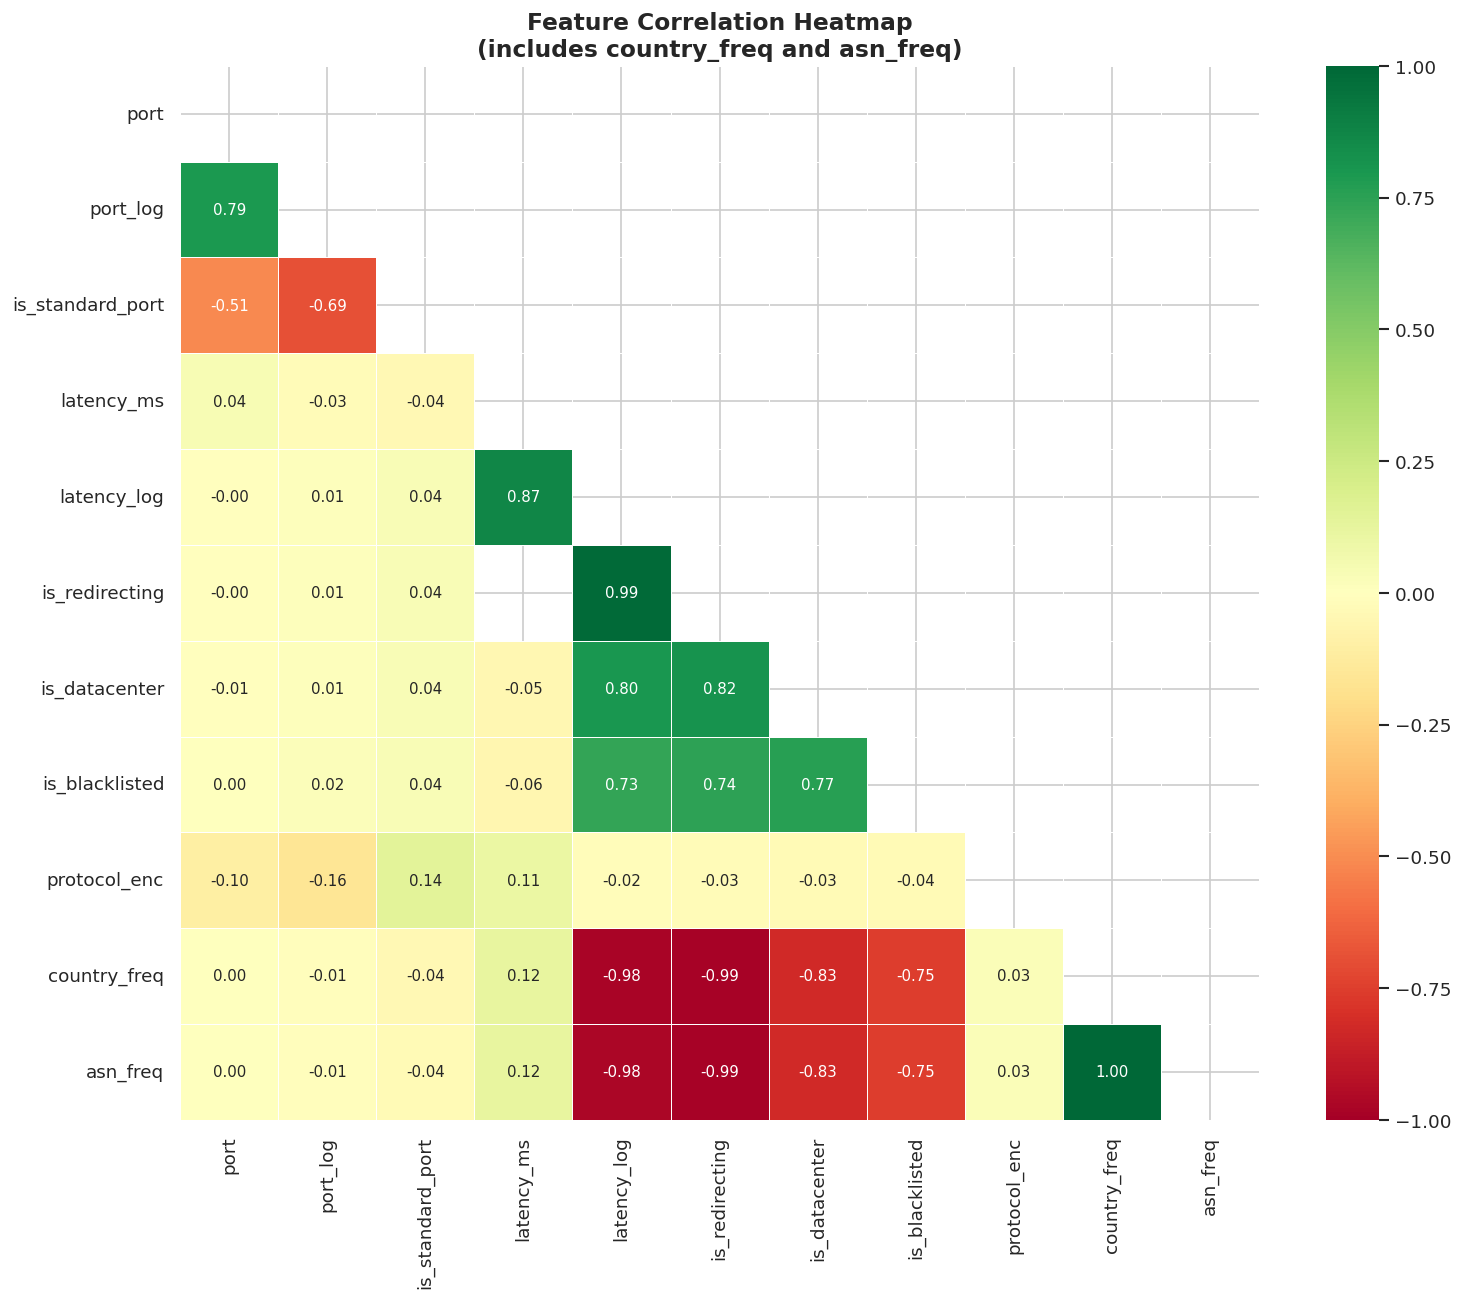

In [4]:
numeric_cols = [
    'port', 'port_log', 'is_standard_port', 'latency_ms', 'latency_log',
    'is_redirecting', 'is_datacenter', 'is_blacklisted', 'protocol_enc',
    'country_freq', 'asn_freq',
]

corr = df[numeric_cols].astype(float).corr()

fig, ax = plt.subplots(figsize=(13, 11))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
    center=0, vmin=-1, vmax=1, linewidths=0.5,
    ax=ax, annot_kws={'size': 9},
)
ax.set_title('Feature Correlation Heatmap\n(includes country_freq and asn_freq)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 3. Supervised: Predicting Availability (is_redirecting)

Can we predict from **static config metadata alone** (protocol, port, port class) whether a config will be reachable?  
This answers: *does the choice of protocol / port correlate with availability?*

Logistic Regression        ROC-AUC=0.676±0.016  F1-macro=0.465±0.003
Random Forest              ROC-AUC=0.755±0.012  F1-macro=0.497±0.002
Gradient Boosting          ROC-AUC=0.756±0.012  F1-macro=0.520±0.006

ROC-AUC is the primary metric — F1-macro accounts for 98.7% class imbalance.


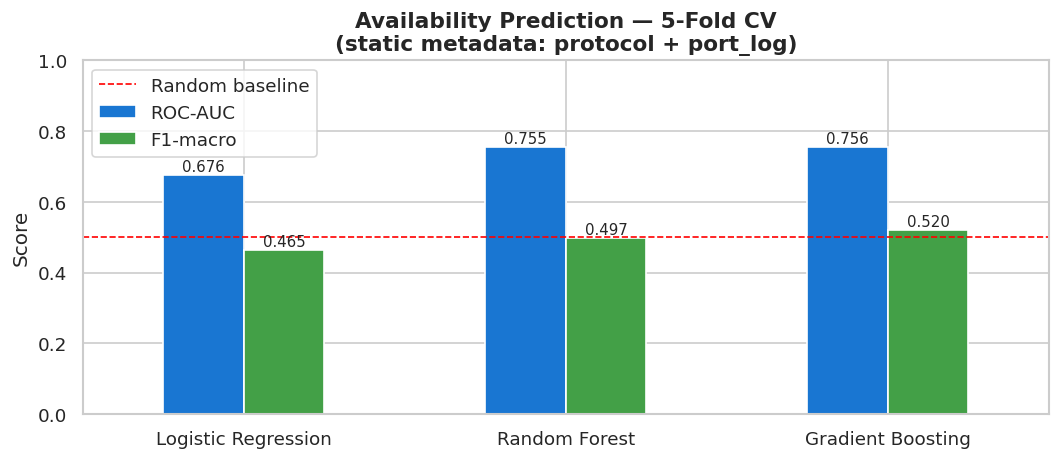

In [5]:
# port_log and port are correlated at 0.79 — using both inflates RF importance
# and splits the same signal twice. Keep port_log (log-scale is better for port range).
AVAIL_FEATURES = ['protocol_enc', 'port_log', 'is_standard_port']
X_avail = df[AVAIL_FEATURES].values
y_avail = df['is_redirecting'].astype(int).values

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models = {
    'Logistic Regression': LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42, n_jobs=-1),
    'Gradient Boosting':   GradientBoostingClassifier(n_estimators=150, random_state=42),
}

# f1_macro gives balanced view across both classes despite 98.7% imbalance
# f1_binary (default) would report near-zero because the minority class is almost never predicted
results_avail = {}
for name, model in models.items():
    pipe = Pipeline([('scaler', StandardScaler()), ('clf', model)])
    auc = cross_val_score(pipe, X_avail, y_avail, cv=cv, scoring='roc_auc', n_jobs=-1)
    f1  = cross_val_score(pipe, X_avail, y_avail, cv=cv, scoring='f1_macro', n_jobs=-1)
    results_avail[name] = {'ROC-AUC': auc.mean(), 'F1-macro': f1.mean()}
    print(f'{name:<25}  ROC-AUC={auc.mean():.3f}±{auc.std():.3f}  F1-macro={f1.mean():.3f}±{f1.std():.3f}')

print('\nROC-AUC is the primary metric — F1-macro accounts for 98.7% class imbalance.')

_save_text_page(pdf,
    pd.DataFrame(results_avail).T.to_string(),
    title='3. Availability Prediction — 5-Fold CV Scores')

res_df = pd.DataFrame(results_avail).T
fig, ax = plt.subplots(figsize=(9, 4))
res_df.plot(kind='bar', ax=ax, color=['#1976D2', '#43A047'], edgecolor='white', rot=0)
ax.set_ylim(0, 1)
ax.set_title('Availability Prediction — 5-Fold CV\n(static metadata: protocol + port_log)', fontsize=13, fontweight='bold')
ax.set_ylabel('Score')
ax.axhline(0.5, color='red', linestyle='--', linewidth=1, label='Random baseline')
ax.legend()
for p in ax.patches:
    ax.annotate(f'{p.get_height():.3f}', (p.get_x() + p.get_width()/2, p.get_height() + 0.01),
                ha='center', fontsize=9)
plt.tight_layout()
plt.show()

---
## 4. Feature Importance — What Drives Availability?

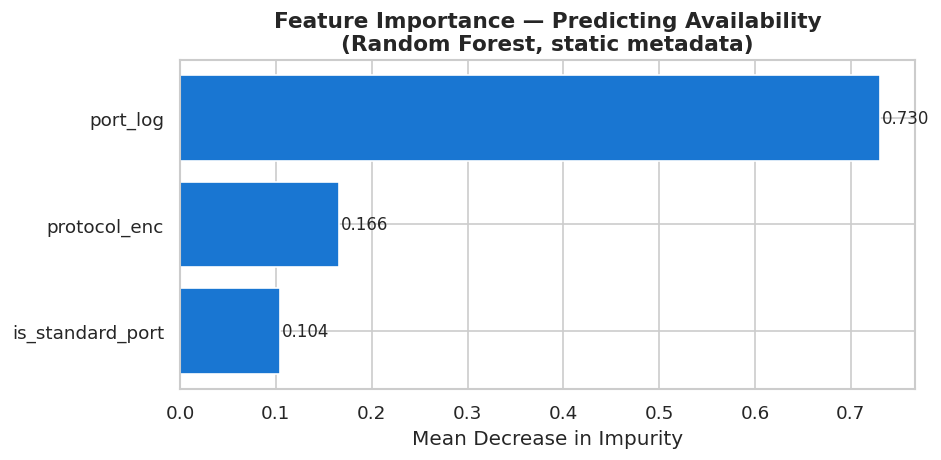

In [6]:
rf = RandomForestClassifier(n_estimators=300, class_weight='balanced', random_state=42, n_jobs=-1)
rf.fit(StandardScaler().fit_transform(X_avail), y_avail)

importances = pd.Series(rf.feature_importances_, index=AVAIL_FEATURES).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(importances.index[::-1], importances.values[::-1], color='#1976D2', edgecolor='white')
for bar, val in zip(bars, importances.values[::-1]):
    ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=10)
ax.set_xlabel('Mean Decrease in Impurity')
ax.set_title('Feature Importance — Predicting Availability\n(Random Forest, static metadata)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 5. Supervised: Predicting Datacenter Exit (is_datacenter)

Among configs that *do* work, can we predict from static metadata whether the exit will be a datacenter?  
This reveals whether protocol/port choices are associated with datacenter infrastructure.

Datacenter dataset: 1451 configs  |  datacenter=973  residential=478
Logistic Regression        ROC-AUC=0.763±0.022  F1-macro=0.689±0.028
Random Forest              ROC-AUC=0.983±0.009  F1-macro=0.934±0.022
Gradient Boosting          ROC-AUC=0.975±0.009  F1-macro=0.919±0.025


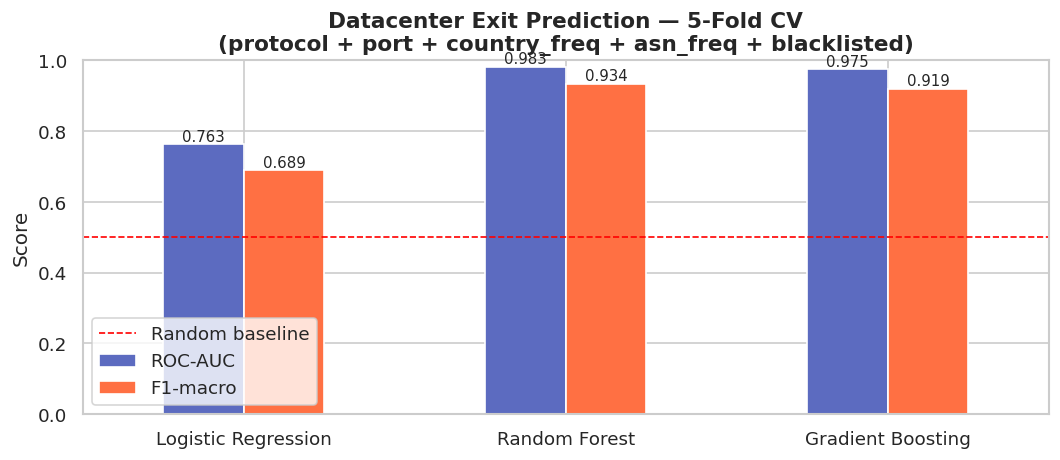

In [7]:
working_df = df[df['is_redirecting']].copy()

DC_FEATURES = [
    'protocol_enc',
    'port_log',
    'is_standard_port',
    'country_freq',
    'asn_freq',
    'is_blacklisted',
]

X_dc = working_df[DC_FEATURES].astype(float).values
y_dc = working_df['is_datacenter'].astype(int).values

n_dc  = y_dc.sum()
n_res = len(y_dc) - n_dc
print(f'Datacenter dataset: {len(working_df)} configs  |  datacenter={n_dc}  residential={n_res}')

cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
models = {
    'Logistic Regression': LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42, n_jobs=-1),
    'Gradient Boosting':   GradientBoostingClassifier(n_estimators=150, random_state=42),
}

results_dc = {}
for name, model in models.items():
    pipe = Pipeline([('scaler', StandardScaler()), ('clf', model)])
    auc = cross_val_score(pipe, X_dc, y_dc, cv=cv5, scoring='roc_auc', n_jobs=-1)
    f1  = cross_val_score(pipe, X_dc, y_dc, cv=cv5, scoring='f1_macro', n_jobs=-1)
    results_dc[name] = {'ROC-AUC': auc.mean(), 'F1-macro': f1.mean()}
    print(f'{name:<25}  ROC-AUC={auc.mean():.3f}±{auc.std():.3f}  F1-macro={f1.mean():.3f}±{f1.std():.3f}')

_save_text_page(pdf, (
    f"Dataset: {len(working_df)} configs  |  datacenter={n_dc}  residential={n_res}\n\n"
    + pd.DataFrame(results_dc).T.to_string()
), title='5. Datacenter Exit Prediction — CV Scores')

res_dc_df = pd.DataFrame(results_dc).T
fig, ax = plt.subplots(figsize=(9, 4))
res_dc_df.plot(kind='bar', ax=ax, color=['#5C6BC0', '#FF7043'], edgecolor='white', rot=0)
ax.set_ylim(0, 1)
ax.set_title('Datacenter Exit Prediction — 5-Fold CV\n(protocol + port + country_freq + asn_freq + blacklisted)', fontsize=13, fontweight='bold')
ax.set_ylabel('Score')
ax.axhline(0.5, color='red', linestyle='--', linewidth=1, label='Random baseline')
ax.legend()
for p in ax.patches:
    ax.annotate(f'{p.get_height():.3f}', (p.get_x() + p.get_width()/2, p.get_height() + 0.01),
                ha='center', fontsize=9)
plt.tight_layout()
plt.show()

---
## 6. Feature Importance — What Predicts Datacenter Exit?

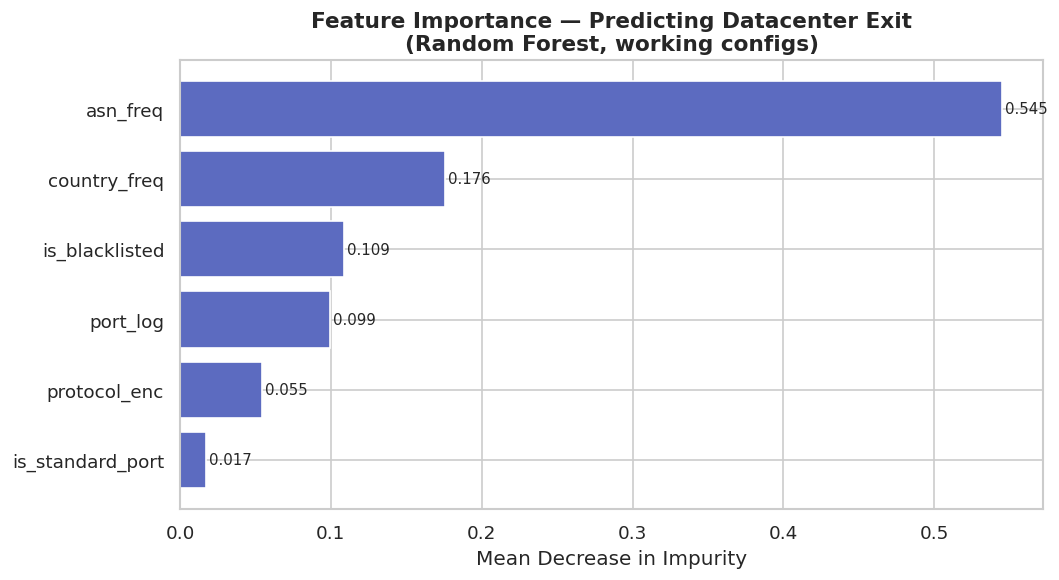

In [8]:
rf_dc = RandomForestClassifier(n_estimators=300, class_weight='balanced', random_state=42, n_jobs=-1)
rf_dc.fit(StandardScaler().fit_transform(X_dc), y_dc)

imp_dc = pd.Series(rf_dc.feature_importances_, index=DC_FEATURES).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(imp_dc.index[::-1], imp_dc.values[::-1], color='#5C6BC0', edgecolor='white')
for bar, val in zip(bars, imp_dc.values[::-1]):
    ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=9)
ax.set_xlabel('Mean Decrease in Impurity')
ax.set_title('Feature Importance — Predicting Datacenter Exit\n(Random Forest, working configs)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 7. Latency Regression — Can We Predict Latency from Config Metadata?

Uses gradient boosting regressor on static features.  
High R² = protocol/geo/port choices are predictive of speed.

Latency Regression (log-scale, target-encoded country):
  R²  = -0.032 ± 0.098
  MAE = 0.915 ± 0.058  (log-ms units)

  Interpretation: R² < 0 means the model is worse than predicting the mean.
  This is an honest finding — latency is driven by real-time network conditions
  (server load, routing path, congestion) that are invisible in static config
  metadata. No amount of ML will fix this; the signal simply is not in the features.


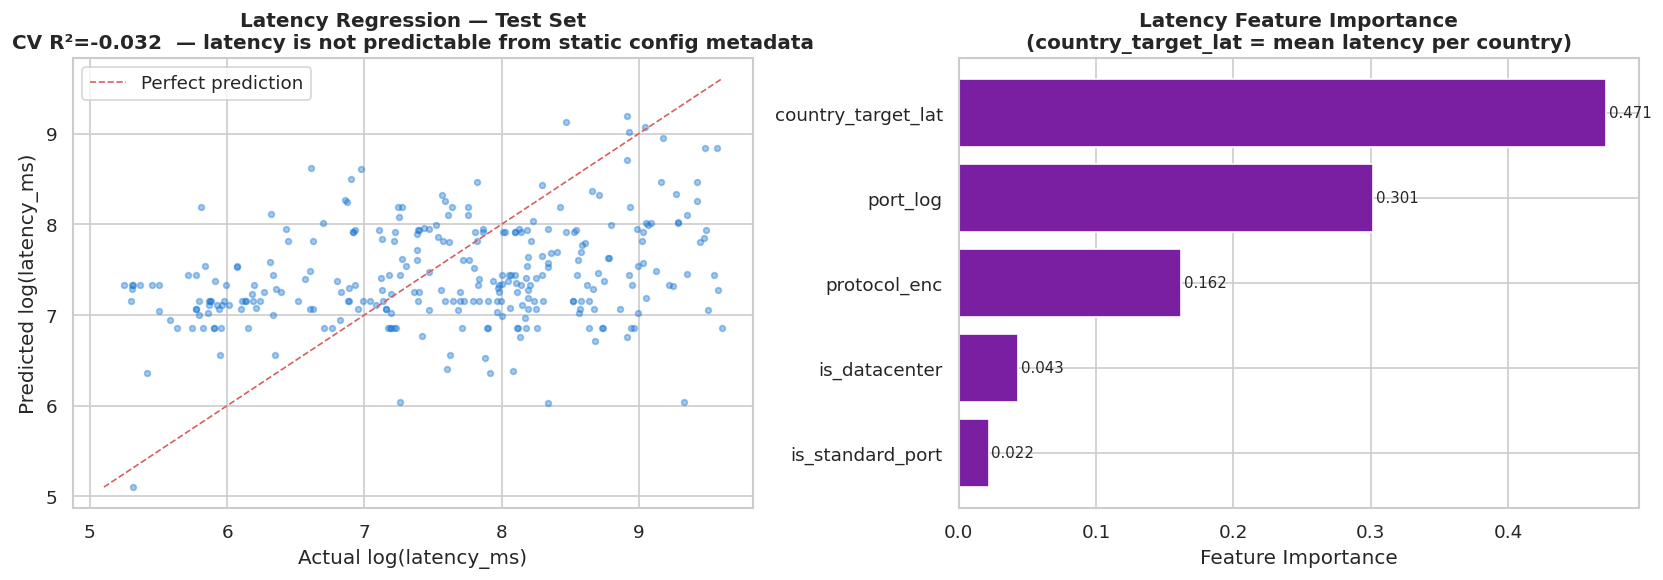

In [9]:
lat_df = working_df.dropna(subset=['latency_ms']).copy()

country_mean_lat = lat_df.groupby('country')['latency_ms'].mean()
global_mean_lat  = lat_df['latency_ms'].mean()
lat_df['country_target_lat'] = lat_df['country'].map(country_mean_lat).fillna(global_mean_lat)

LAT_FEATURES = ['protocol_enc', 'port_log', 'is_standard_port', 'country_target_lat', 'is_datacenter']
X_lat = lat_df[LAT_FEATURES].astype(float).values
y_lat = np.log1p(lat_df['latency_ms'].values)

X_tr, X_te, y_tr, y_te = train_test_split(X_lat, y_lat, test_size=0.2, random_state=42)

gbr = GradientBoostingRegressor(n_estimators=200, max_depth=4, random_state=42)
r2_scores  = cross_val_score(gbr, X_lat, y_lat, cv=5, scoring='r2')
mae_scores = cross_val_score(gbr, X_lat, y_lat, cv=5, scoring='neg_mean_absolute_error')

print('Latency Regression (log-scale, target-encoded country):')
print(f'  R²  = {r2_scores.mean():.3f} ± {r2_scores.std():.3f}')
print(f'  MAE = {-mae_scores.mean():.3f} ± {mae_scores.std():.3f}  (log-ms units)')
print()
print('  Interpretation: R² < 0 means the model is worse than predicting the mean.')
print('  This is an honest finding — latency is driven by real-time network conditions')
print('  (server load, routing path, congestion) that are invisible in static config')
print('  metadata. No amount of ML will fix this; the signal simply is not in the features.')

_save_text_page(pdf, (
    f"Latency Regression (log-scale, target-encoded country):\n"
    f"  R²  = {r2_scores.mean():.3f} ± {r2_scores.std():.3f}\n"
    f"  MAE = {-mae_scores.mean():.3f} ± {mae_scores.std():.3f}  (log-ms units)\n\n"
    f"  R² < 0 means the model is worse than predicting the mean.\n"
    f"  Latency is driven by real-time network conditions (server load,\n"
    f"  routing path, congestion) that are invisible in static config\n"
    f"  metadata. No amount of ML will fix this; the signal is not there."
), title='7. Latency Regression — Results')

gbr.fit(X_tr, y_tr)
y_pred_te = gbr.predict(X_te)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.scatter(y_te, y_pred_te, alpha=0.4, s=12, color='#1976D2')
lim = [min(y_te.min(), y_pred_te.min()), max(y_te.max(), y_pred_te.max())]
ax.plot(lim, lim, 'r--', lw=1, label='Perfect prediction')
ax.set_xlabel('Actual log(latency_ms)')
ax.set_ylabel('Predicted log(latency_ms)')
ax.set_title(
    f'Latency Regression — Test Set\n'
    f'CV R²={r2_scores.mean():.3f}  — latency is not predictable from static config metadata',
    fontweight='bold'
)
ax.legend()

ax2 = axes[1]
gbr_full = GradientBoostingRegressor(n_estimators=200, max_depth=4, random_state=42)
gbr_full.fit(X_lat, y_lat)
lat_imp = pd.Series(gbr_full.feature_importances_, index=LAT_FEATURES).sort_values(ascending=False)
bars = ax2.barh(lat_imp.index[::-1], lat_imp.values[::-1], color='#7B1FA2', edgecolor='white')
for bar, val in zip(bars, lat_imp.values[::-1]):
    ax2.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
             f'{val:.3f}', va='center', fontsize=9)
ax2.set_xlabel('Feature Importance')
ax2.set_title('Latency Feature Importance\n(country_target_lat = mean latency per country)', fontweight='bold')

plt.tight_layout()
plt.show()

---
## 8. Unsupervised Clustering — K-Means on Working Configs

Groups configs by protocol, latency, geo, datacenter status.  
Reveals natural config archetypes (e.g., fast datacenter, slow residential, etc.).

Silhouette scores:
  k= 2  0.6731  ← best
  k= 3  0.3040
  k= 4  0.2836
  k= 5  0.3007
  k= 6  0.3157
  k= 7  0.3423
  k= 8  0.3505
  k= 9  0.3562
  k=10  0.3538
  k=11  0.3509
  k=12  0.3770


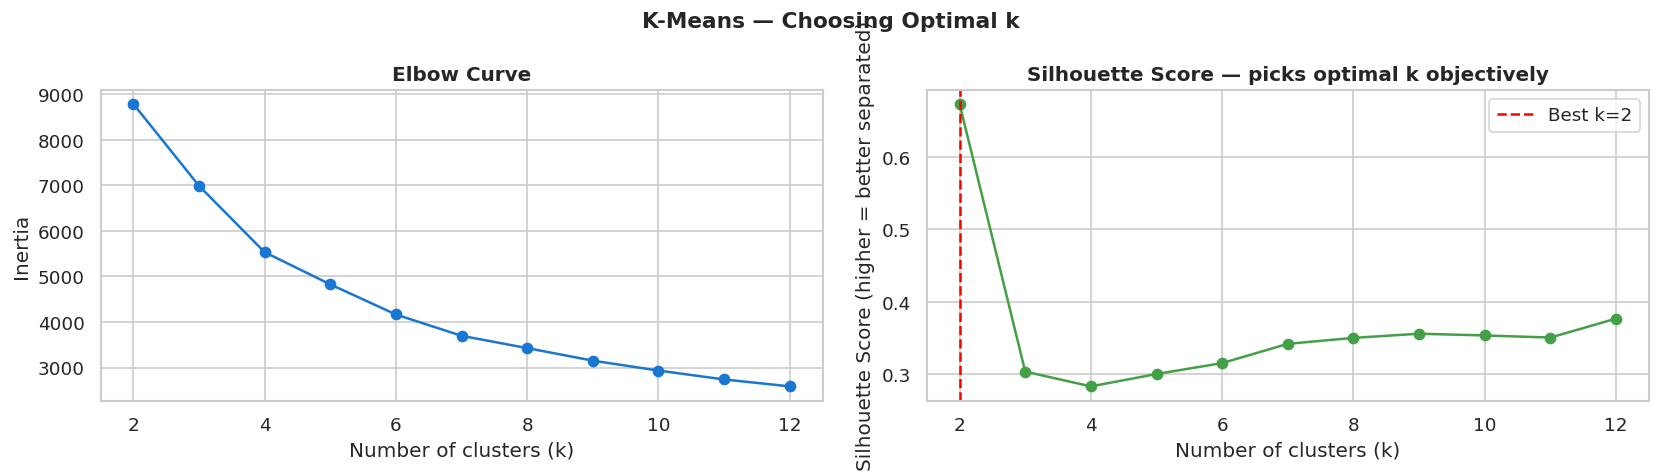

In [10]:
CLUSTER_FEATURES = [
    'protocol_enc', 'port_log', 'is_standard_port',
    'latency_log', 'is_datacenter', 'is_blacklisted', 'country_freq', 'asn_freq',
]
X_clust = working_df[CLUSTER_FEATURES].astype(float).fillna(0).values
X_clust_scaled = StandardScaler().fit_transform(X_clust)

inertias    = []
silhouettes = []
K_RANGE = range(2, 13)
for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_k = km.fit_predict(X_clust_scaled)
    inertias.append(km.inertia_)
    sil = silhouette_score(X_clust_scaled, labels_k,
                           sample_size=min(500, len(X_clust_scaled)), random_state=42)
    silhouettes.append(sil)

best_k = list(K_RANGE)[int(np.argmax(silhouettes))]
print('Silhouette scores:')
for k, s in zip(K_RANGE, silhouettes):
    marker = '  ← best' if k == best_k else ''
    print(f'  k={k:2d}  {s:.4f}{marker}')

_save_text_page(pdf, (
    'Silhouette scores (higher = better separated clusters):\n\n' +
    '\n'.join(
        f'  k={k:2d}  {s:.4f}{"  ← best" if k == best_k else ""}'
        for k, s in zip(K_RANGE, silhouettes)
    )
), title='8. K-Means Silhouette Scores by k')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

ax = axes[0]
ax.plot(list(K_RANGE), inertias, 'o-', color='#1976D2')
ax.set_xlabel('Number of clusters (k)')
ax.set_ylabel('Inertia')
ax.set_title('Elbow Curve', fontweight='bold')

ax2 = axes[1]
ax2.plot(list(K_RANGE), silhouettes, 'o-', color='#43A047')
ax2.axvline(best_k, color='red', linestyle='--', label=f'Best k={best_k}')
ax2.set_xlabel('Number of clusters (k)')
ax2.set_ylabel('Silhouette Score (higher = better separated)')
ax2.set_title('Silhouette Score — picks optimal k objectively', fontweight='bold')
ax2.legend()

plt.suptitle('K-Means — Choosing Optimal k', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [11]:
K_BEST = best_k
km_final = KMeans(n_clusters=K_BEST, random_state=42, n_init=20)
working_df = working_df.copy()
working_df['cluster'] = km_final.fit_predict(X_clust_scaled)

agg_dict = dict(
    count          = ('cluster', 'size'),
    avg_latency    = ('latency_ms', 'mean'),
    pct_datacenter = ('is_datacenter', 'mean'),
    pct_blacklist  = ('is_blacklisted', 'mean'),
    top_protocol   = ('protocol', lambda x: x.mode()[0]),
    top_country    = ('country', lambda x: x.mode()[0] if x.notna().any() else 'Unknown'),
)
if 'proxy_detected' in working_df.columns:
    agg_dict['pct_proxy_det'] = ('proxy_detected', 'mean')
if 'has_ipv6' in working_df.columns:
    agg_dict['pct_ipv6'] = ('has_ipv6', 'mean')

cluster_profile = working_df.groupby('cluster').agg(**agg_dict).round(3)
cluster_profile['pct_datacenter'] = (cluster_profile['pct_datacenter'] * 100).round(1)
cluster_profile['pct_blacklist']  = (cluster_profile['pct_blacklist']  * 100).round(1)
if 'pct_proxy_det' in cluster_profile.columns:
    cluster_profile['pct_proxy_det'] = (cluster_profile['pct_proxy_det'] * 100).round(1)
if 'pct_ipv6' in cluster_profile.columns:
    cluster_profile['pct_ipv6'] = (cluster_profile['pct_ipv6'] * 100).round(1)

print(f'k={K_BEST} selected by silhouette score\n')
print(cluster_profile.to_string())

_save_text_page(pdf,
    f'k={K_BEST} selected by silhouette score\n\n' + cluster_profile.to_string(),
    title=f'8b. Cluster Profile (k={K_BEST})')

k=2 selected by silhouette score

         count  avg_latency  pct_datacenter  pct_blacklist top_protocol     top_country  pct_proxy_det  pct_ipv6
cluster                                                                                                         
0         1418     2966.512            68.6           57.0        vless         Germany           56.8      27.4
1           33     5446.651             0.0            0.0        vless  United Kingdom           27.3      15.2


---
## 9. t-SNE Visualization of Config Clusters

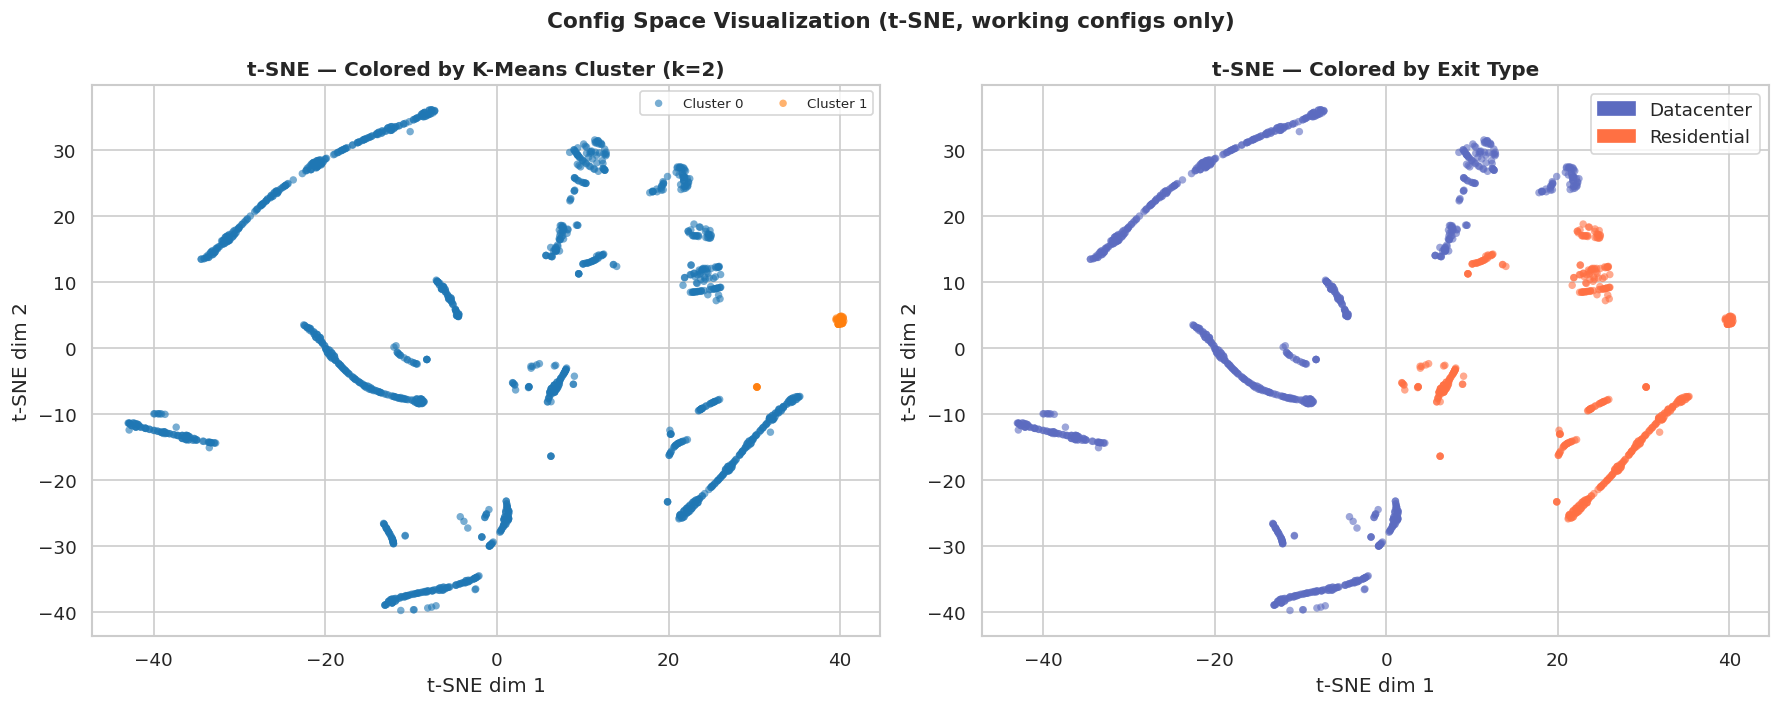

In [12]:
tsne_iter_kwarg = {'n_iter': 1000} if USE_GPU else {'max_iter': 1000}
tsne = TSNE(n_components=2, perplexity=40, random_state=42, **tsne_iter_kwarg)
X_2d = tsne.fit_transform(X_clust_scaled)

palette = sns.color_palette('tab10', K_BEST)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

ax = axes[0]
for cluster_id in range(K_BEST):
    mask = working_df['cluster'] == cluster_id
    ax.scatter(X_2d[mask, 0], X_2d[mask, 1],
               c=[palette[cluster_id]], label=f'Cluster {cluster_id}',
               alpha=0.6, s=20, edgecolors='none')
ax.set_title(f't-SNE — Colored by K-Means Cluster (k={K_BEST})', fontweight='bold')
ax.legend(fontsize=8, ncol=2)
ax.set_xlabel('t-SNE dim 1')
ax.set_ylabel('t-SNE dim 2')

ax2 = axes[1]
dc_colors = np.where(working_df['is_datacenter'], '#5C6BC0', '#FF7043')
ax2.scatter(X_2d[:, 0], X_2d[:, 1], c=dc_colors, alpha=0.6, s=20, edgecolors='none')
from matplotlib.patches import Patch
ax2.legend(handles=[Patch(color='#5C6BC0', label='Datacenter'), Patch(color='#FF7043', label='Residential')])
ax2.set_title('t-SNE — Colored by Exit Type', fontweight='bold')
ax2.set_xlabel('t-SNE dim 1')
ax2.set_ylabel('t-SNE dim 2')

plt.suptitle('Config Space Visualization (t-SNE, working configs only)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 10. Cluster Profile — Radar / Bar Summary

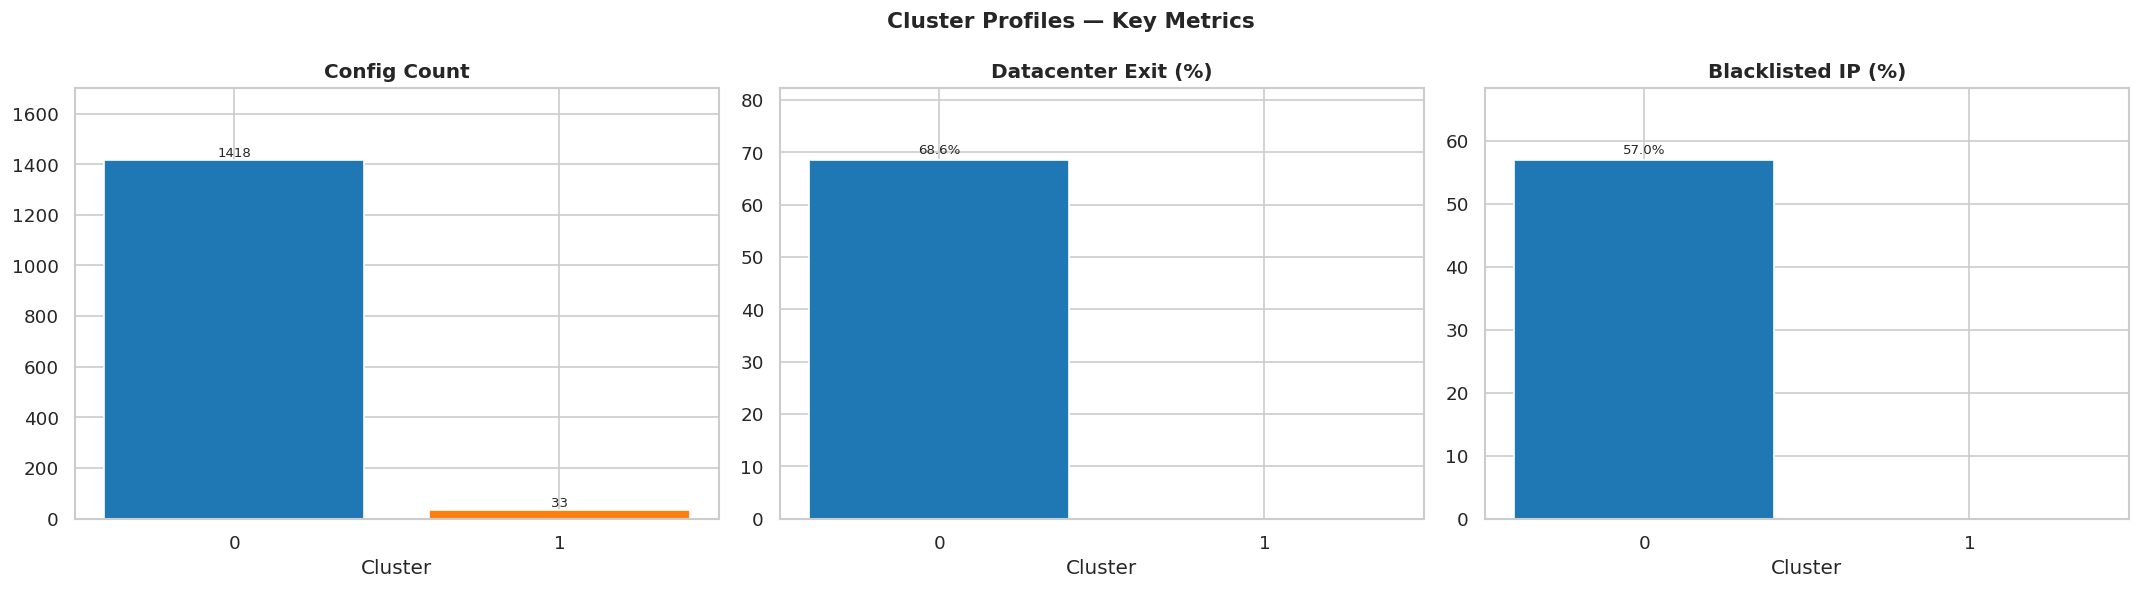

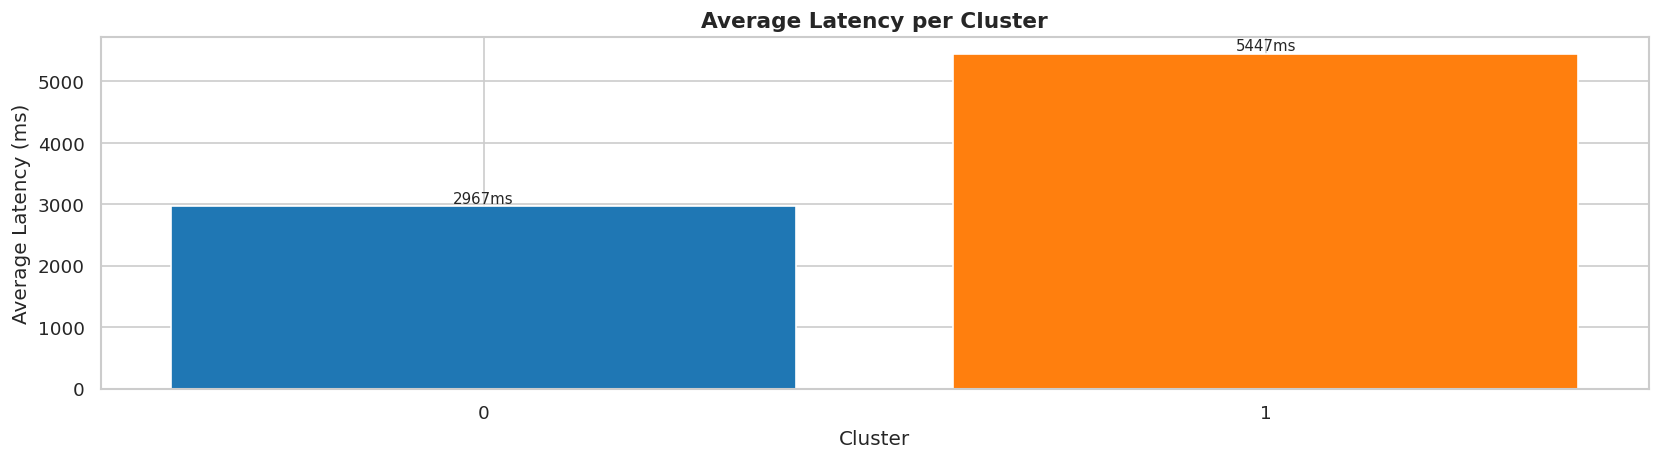

In [13]:
colors_c = sns.color_palette('tab10', K_BEST)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
panels = [
    ('count',          'Config Count',        '{:.0f}'),
    ('pct_datacenter', 'Datacenter Exit (%)', '{:.1f}%'),
    ('pct_blacklist',  'Blacklisted IP (%)',  '{:.1f}%'),
]

for i, (col, title, fmt) in enumerate(panels):
    ax = axes[i]
    bars = ax.bar(cluster_profile.index.astype(str), cluster_profile[col],
                  color=colors_c, edgecolor='white')
    for bar, val in zip(bars, cluster_profile[col]):
        if val > 0:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                    fmt.format(val), ha='center', va='bottom', fontsize=8)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Cluster')
    ax.set_ylim(0, max(cluster_profile[col].max() * 1.2, 10))

plt.suptitle('Cluster Profiles — Key Metrics', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

fig2, ax = plt.subplots(figsize=(14, 4))
bars = ax.bar(cluster_profile.index.astype(str), cluster_profile['avg_latency'],
              color=colors_c, edgecolor='white')
for bar, val in zip(bars, cluster_profile['avg_latency']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            f'{val:.0f}ms', ha='center', va='bottom', fontsize=9)
ax.set_xlabel('Cluster')
ax.set_ylabel('Average Latency (ms)')
ax.set_title('Average Latency per Cluster', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 11. Anomaly Detection — Isolation Forest

Finds configs that are outliers in the multi-dimensional feature space.  
Anomalies among *working* configs may represent unusual infrastructure or sophisticated setups.

Normal configs   : 1380
Anomalous configs: 71

Anomaly breakdown:
  Protocol dist  :
protocol
vless        33
ss           14
hysteria2    13
vmess        10
trojan        1

  Avg latency    : 3552ms  (normal: 2996ms)
  Datacenter pct : 21.1%  (normal: 69.4%)
  Blacklisted pct: 36.6%  (normal: 56.7%)


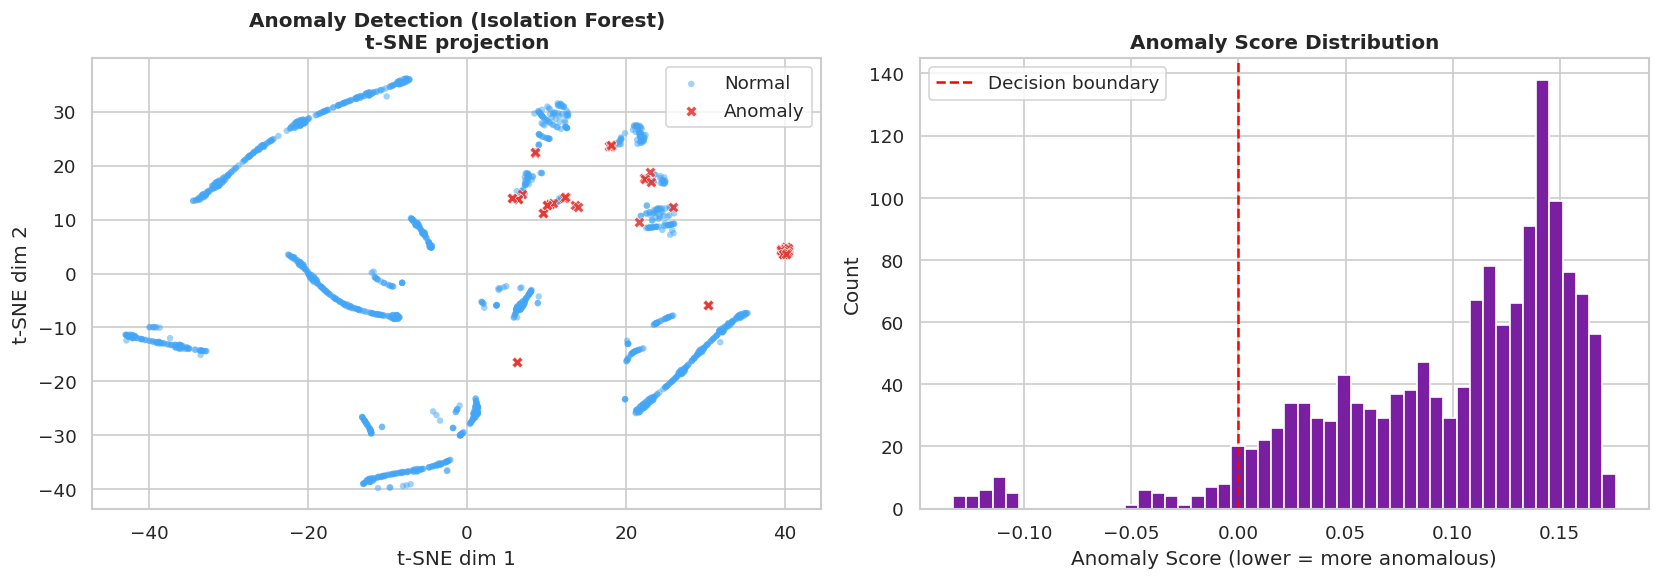

In [14]:
iso = IsolationForest(contamination=0.05, random_state=42, n_jobs=-1)
working_df = working_df.copy()
working_df['anomaly_score']     = iso.fit_predict(X_clust_scaled)
working_df['anomaly_score_raw'] = iso.decision_function(X_clust_scaled)

anomalies = working_df[working_df['anomaly_score'] == -1]
normal    = working_df[working_df['anomaly_score'] == 1]

print(f'Normal configs   : {len(normal)}')
print(f'Anomalous configs: {len(anomalies)}')
print(f'\nAnomaly breakdown:')
print(f'  Protocol dist  :\n{anomalies["protocol"].value_counts().to_string()}')
print(f'\n  Avg latency    : {anomalies["latency_ms"].mean():.0f}ms  (normal: {normal["latency_ms"].mean():.0f}ms)')
print(f'  Datacenter pct : {anomalies["is_datacenter"].mean()*100:.1f}%  (normal: {normal["is_datacenter"].mean()*100:.1f}%)')
print(f'  Blacklisted pct: {anomalies["is_blacklisted"].mean()*100:.1f}%  (normal: {normal["is_blacklisted"].mean()*100:.1f}%)')

_save_text_page(pdf, (
    f"Normal configs   : {len(normal)}\n"
    f"Anomalous configs: {len(anomalies)}\n\n"
    f"Anomaly breakdown:\n"
    f"  Protocol distribution:\n"
    + '\n'.join(f'    {l}' for l in anomalies['protocol'].value_counts().to_string().splitlines()) +
    f"\n\n"
    f"  Avg latency    : {anomalies['latency_ms'].mean():.0f}ms  (normal: {normal['latency_ms'].mean():.0f}ms)\n"
    f"  Datacenter pct : {anomalies['is_datacenter'].mean()*100:.1f}%  (normal: {normal['is_datacenter'].mean()*100:.1f}%)\n"
    f"  Blacklisted pct: {anomalies['is_blacklisted'].mean()*100:.1f}%  (normal: {normal['is_blacklisted'].mean()*100:.1f}%)"
), title='11. Anomaly Detection — Breakdown')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.scatter(X_2d[working_df['anomaly_score']==1, 0], X_2d[working_df['anomaly_score']==1, 1],
           c='#42A5F5', alpha=0.5, s=15, label='Normal', edgecolors='none')
ax.scatter(X_2d[working_df['anomaly_score']==-1, 0], X_2d[working_df['anomaly_score']==-1, 1],
           c='#E53935', alpha=0.9, s=40, label='Anomaly', marker='X', edgecolors='white', linewidths=0.3)
ax.set_title('Anomaly Detection (Isolation Forest)\nt-SNE projection', fontweight='bold')
ax.legend()
ax.set_xlabel('t-SNE dim 1')
ax.set_ylabel('t-SNE dim 2')

ax2 = axes[1]
ax2.hist(working_df['anomaly_score_raw'], bins=50, color='#7B1FA2', edgecolor='white')
ax2.axvline(0, color='red', linestyle='--', label='Decision boundary')
ax2.set_xlabel('Anomaly Score (lower = more anomalous)')
ax2.set_ylabel('Count')
ax2.set_title('Anomaly Score Distribution', fontweight='bold')
ax2.legend()

plt.tight_layout()
plt.show()

---
## 12. Protocol × Geography — Datacenter Exit Rate

Which protocol/country combinations most consistently use datacenter infrastructure?

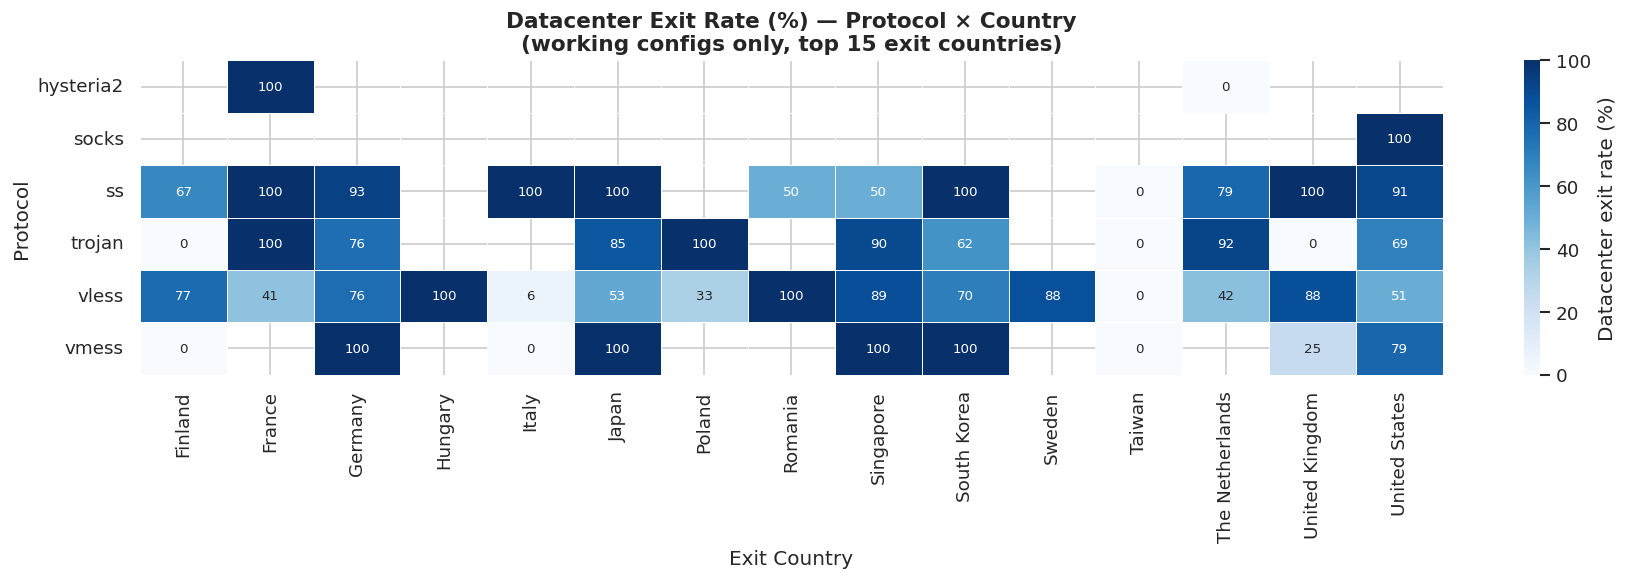

In [15]:
top_countries_w = working_df['country'].value_counts().head(15).index.tolist()
subset_w = working_df[working_df['country'].isin(top_countries_w)].copy()

pivot = subset_w.pivot_table(
    values='is_datacenter',
    index='protocol',
    columns='country',
    aggfunc='mean',
) * 100

pivot = pivot.loc[pivot.notna().any(axis=1)]

fig, ax = plt.subplots(figsize=(15, 5))
sns.heatmap(
    pivot, annot=True, fmt='.0f', cmap='Blues',
    linewidths=0.5, ax=ax, annot_kws={'size': 8},
    cbar_kws={'label': 'Datacenter exit rate (%)'},
    vmin=0, vmax=100,
)
ax.set_title('Datacenter Exit Rate (%) — Protocol × Country\n(working configs only, top 15 exit countries)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Exit Country')
ax.set_ylabel('Protocol')
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, va='center')
plt.tight_layout()
plt.show()

---
## 13. Port Number Analysis — Availability by Port Range

Tests whether configs on standard ports (80, 443) are more likely to be reachable.

   is_standard_port  available  total  avail_rate  avail_rate_pct                          label
0                 0        336  45731    0.007347        0.734731             Non-standard ports
1                 1       1115  69311    0.016087        1.608691  Standard ports (80/443/8080…)


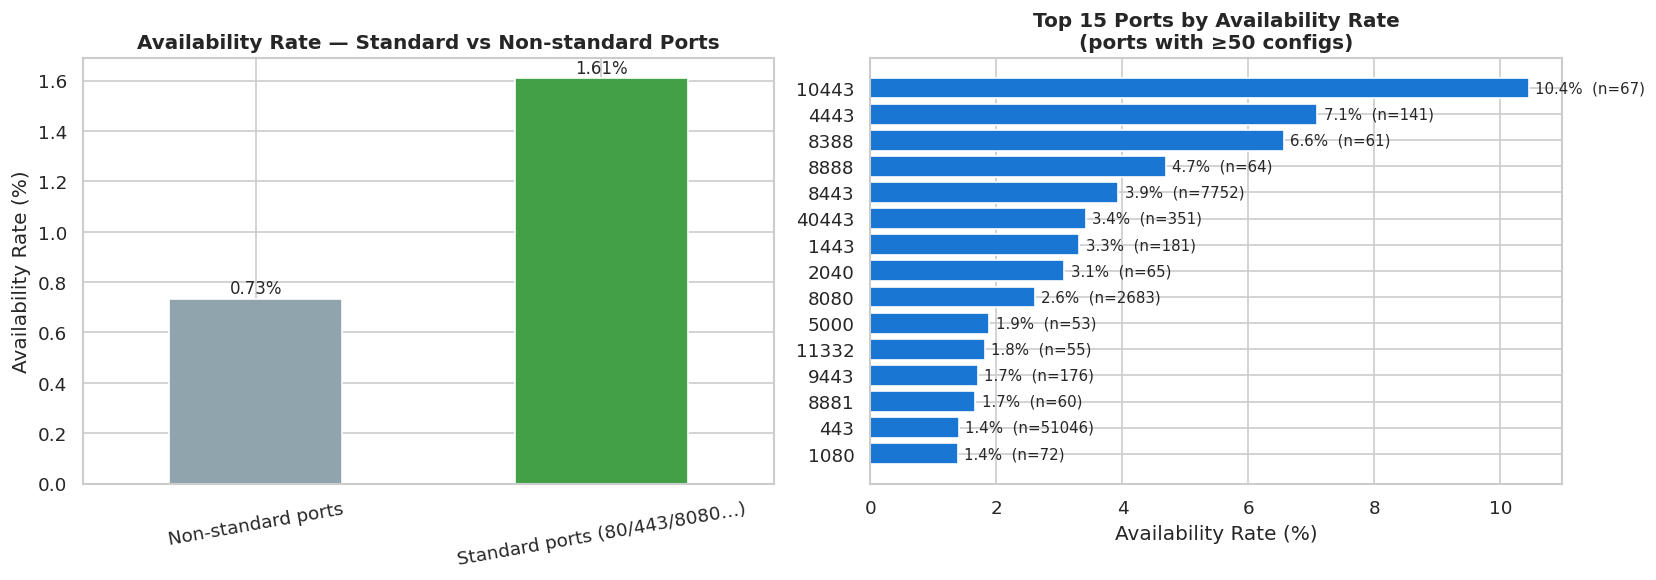

In [16]:
port_avail = df.groupby('is_standard_port')['is_redirecting'].agg(['sum', 'count', 'mean']).reset_index()
port_avail.columns = ['is_standard_port', 'available', 'total', 'avail_rate']
port_avail['avail_rate_pct'] = port_avail['avail_rate'] * 100  # convert to % for plotting
port_avail['label'] = port_avail['is_standard_port'].map({0: 'Non-standard ports', 1: 'Standard ports (80/443/8080…)'})
print(port_avail.to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
port_avail.plot(
    kind='bar', x='label', y='avail_rate_pct', ax=ax,
    color=['#90A4AE', '#43A047'], edgecolor='white', legend=False, rot=10,
)
ax.set_ylabel('Availability Rate (%)')
ax.set_title('Availability Rate — Standard vs Non-standard Ports', fontweight='bold')
ax.set_xlabel('')
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}%', (p.get_x() + p.get_width()/2, p.get_height() + 0.02),
                ha='center', fontsize=10)

ax2 = axes[1]
top_ports = df.groupby('port')['is_redirecting'].agg(['sum', 'count']).reset_index()
top_ports = top_ports[top_ports['count'] >= 50].copy()
top_ports['avail_rate'] = top_ports['sum'] / top_ports['count']
top_ports = top_ports.sort_values('avail_rate', ascending=False).head(15)

bars = ax2.barh(top_ports['port'].astype(str).iloc[::-1], top_ports['avail_rate'].iloc[::-1] * 100,
                color='#1976D2', edgecolor='white')
for bar, (_, row) in zip(bars, top_ports.iloc[::-1].iterrows()):
    ax2.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
             f"{row['avail_rate']*100:.1f}%  (n={int(row['count'])})", va='center', fontsize=9)
ax2.set_xlabel('Availability Rate (%)')
ax2.set_title('Top 15 Ports by Availability Rate\n(ports with ≥50 configs)', fontweight='bold')

plt.tight_layout()
plt.show()

---
## 14. PCA — Principal Components of Working Config Space

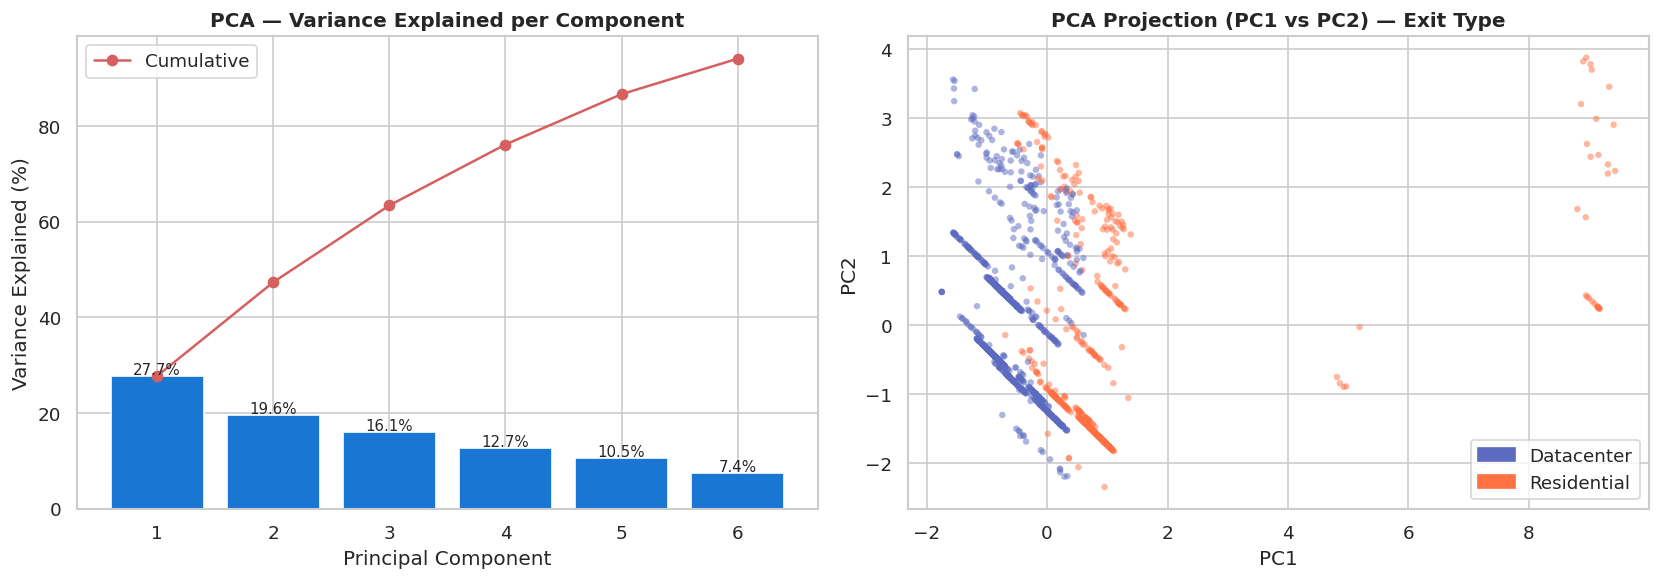


Feature loadings on PC1 and PC2:
                       PC1       PC2
asn_freq          0.582153  0.134568
country_freq      0.575427  0.156866
protocol_enc      0.203395 -0.242077
latency_log       0.153878 -0.131530
port_log         -0.043319  0.674882
is_standard_port -0.125333 -0.577210
is_blacklisted   -0.341598  0.272504
is_datacenter    -0.361469  0.135969


In [17]:
pca = PCA(n_components=6)
X_pca = pca.fit_transform(X_clust_scaled)

explained  = pca.explained_variance_ratio_
cumulative = np.cumsum(explained)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.bar(range(1, len(explained)+1), explained * 100, color='#1976D2', edgecolor='white')
ax.plot(range(1, len(explained)+1), cumulative * 100, 'ro-', label='Cumulative')
ax.set_xlabel('Principal Component')
ax.set_ylabel('Variance Explained (%)')
ax.set_title('PCA — Variance Explained per Component', fontweight='bold')
ax.legend()
for i, (ev, cum) in enumerate(zip(explained, cumulative)):
    ax.text(i+1, ev*100 + 0.3, f'{ev*100:.1f}%', ha='center', fontsize=9)

ax2 = axes[1]
dc_colors = np.where(working_df['is_datacenter'], '#5C6BC0', '#FF7043')
ax2.scatter(X_pca[:, 0], X_pca[:, 1], c=dc_colors, alpha=0.5, s=15, edgecolors='none')
from matplotlib.patches import Patch
ax2.legend(handles=[Patch(color='#5C6BC0', label='Datacenter'), Patch(color='#FF7043', label='Residential')])
ax2.set_xlabel('PC1')
ax2.set_ylabel('PC2')
ax2.set_title('PCA Projection (PC1 vs PC2) — Exit Type', fontweight='bold')

plt.tight_layout()
plt.show()

component_df = pd.DataFrame(
    pca.components_[:2], columns=CLUSTER_FEATURES,
    index=['PC1', 'PC2']
).T
print('\nFeature loadings on PC1 and PC2:')
print(component_df.sort_values('PC1', ascending=False).to_string())

_save_text_page(pdf,
    component_df.sort_values('PC1', ascending=False).to_string(),
    title='14. PCA Feature Loadings — PC1 and PC2')

---
## 15. Deep Learning — MLP Availability Classifier

A simple multi-layer perceptron to predict config availability (is_redirecting) from static metadata.  
Compare against the RF baseline from section 3.

In [18]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

scaler_nn = StandardScaler()
X_nn = scaler_nn.fit_transform(X_avail)
y_nn = y_avail.astype(np.float32)

X_tr, X_te, y_tr, y_te = train_test_split(X_nn, y_nn, test_size=0.2, stratify=y_nn, random_state=42)

pos_weight = torch.tensor([(y_tr == 0).sum() / max((y_tr == 1).sum(), 1)], dtype=torch.float32)

train_ds = TensorDataset(torch.FloatTensor(X_tr), torch.FloatTensor(y_tr))
test_ds  = TensorDataset(torch.FloatTensor(X_te), torch.FloatTensor(y_te))
train_dl = DataLoader(train_ds, batch_size=64, shuffle=True, drop_last=True)
test_dl  = DataLoader(test_ds,  batch_size=256)


class AvailabilityMLP(nn.Module):
    def __init__(self, in_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 128), nn.BatchNorm1d(128), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(128, 64),     nn.BatchNorm1d(64),  nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(64, 32),      nn.ReLU(),
            nn.Linear(32, 1),
        )
    def forward(self, x):
        return self.net(x).squeeze(1)


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Training on: {device}')

model = AvailabilityMLP(X_nn.shape[1]).to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight.to(device))
optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=50)

train_losses, val_aucs = [], []
EPOCHS = 60

for epoch in range(EPOCHS):
    model.train()
    epoch_loss = 0
    for xb, yb in train_dl:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        loss = criterion(model(xb), yb)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * len(xb)
    scheduler.step()
    train_losses.append(epoch_loss / len(train_ds))

    model.eval()
    all_probs, all_labels = [], []
    with torch.no_grad():
        for xb, yb in test_dl:
            probs = torch.sigmoid(model(xb.to(device))).cpu().numpy()
            all_probs.extend(probs)
            all_labels.extend(yb.numpy())
    try:
        val_aucs.append(roc_auc_score(all_labels, all_probs))
    except Exception:
        val_aucs.append(0.5)

    if (epoch + 1) % 10 == 0:
        print(f'Epoch {epoch+1:3d}/{EPOCHS}  loss={train_losses[-1]:.4f}  val_AUC={val_aucs[-1]:.4f}')

print(f'\nFinal test ROC-AUC: {val_aucs[-1]:.4f}')
preds_bin = (np.array(all_probs) >= 0.5).astype(int)
print(classification_report(all_labels, preds_bin, target_names=['Unavailable', 'Available']))

Training on: cuda
Epoch  10/60  loss=1.2163  val_AUC=0.7097
Epoch  20/60  loss=1.2052  val_AUC=0.7102
Epoch  30/60  loss=1.1953  val_AUC=0.7143
Epoch  40/60  loss=1.1889  val_AUC=0.7147
Epoch  50/60  loss=1.1829  val_AUC=0.7152
Epoch  60/60  loss=1.1903  val_AUC=0.7113

Final test ROC-AUC: 0.7113
              precision    recall  f1-score   support

 Unavailable       0.99      0.79      0.88     22719
   Available       0.03      0.52      0.06       290

    accuracy                           0.79     23009
   macro avg       0.51      0.66      0.47     23009
weighted avg       0.98      0.79      0.87     23009



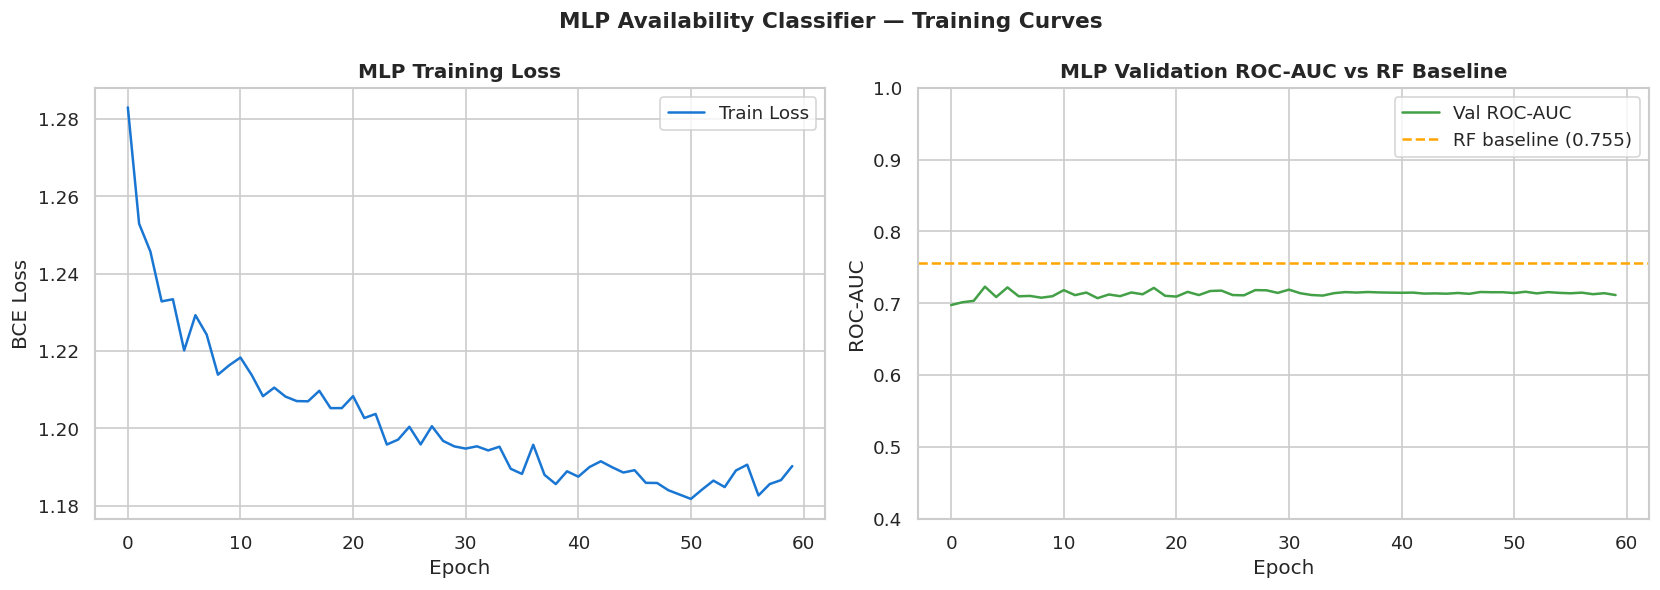

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(train_losses, color='#1976D2', label='Train Loss')
ax.set_xlabel('Epoch')
ax.set_ylabel('BCE Loss')
ax.set_title('MLP Training Loss', fontweight='bold')
ax.legend()

ax2 = axes[1]
ax2.plot(val_aucs, color='#43A047', label='Val ROC-AUC')
ax2.axhline(results_avail['Random Forest']['ROC-AUC'], color='orange', linestyle='--',
            label=f'RF baseline ({results_avail["Random Forest"]["ROC-AUC"]:.3f})')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('ROC-AUC')
ax2.set_title('MLP Validation ROC-AUC vs RF Baseline', fontweight='bold')
ax2.legend()
ax2.set_ylim(0.4, 1.0)

plt.suptitle('MLP Availability Classifier — Training Curves', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 16. Confusion Matrix — MLP Availability Classifier

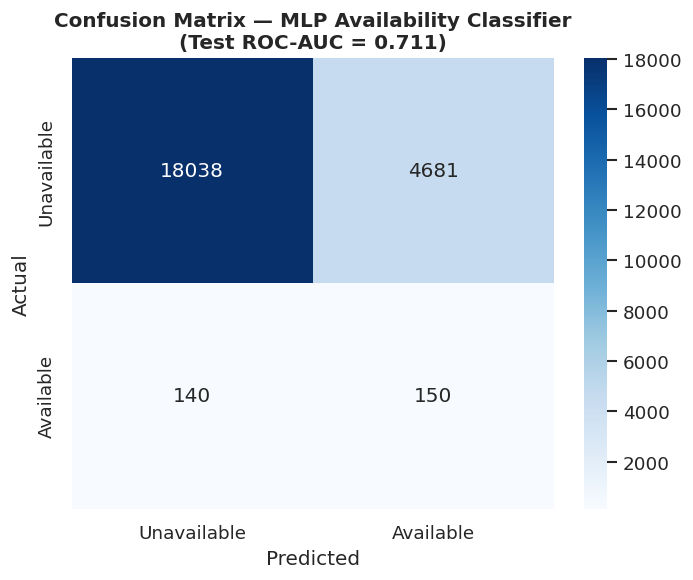

In [20]:
cm = confusion_matrix(all_labels, preds_bin)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Unavailable', 'Available'],
            yticklabels=['Unavailable', 'Available'])
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title(f'Confusion Matrix — MLP Availability Classifier\n(Test ROC-AUC = {val_aucs[-1]:.3f})',
             fontweight='bold')
plt.tight_layout()
plt.show()

---
## 17. Model Comparison — Availability Prediction

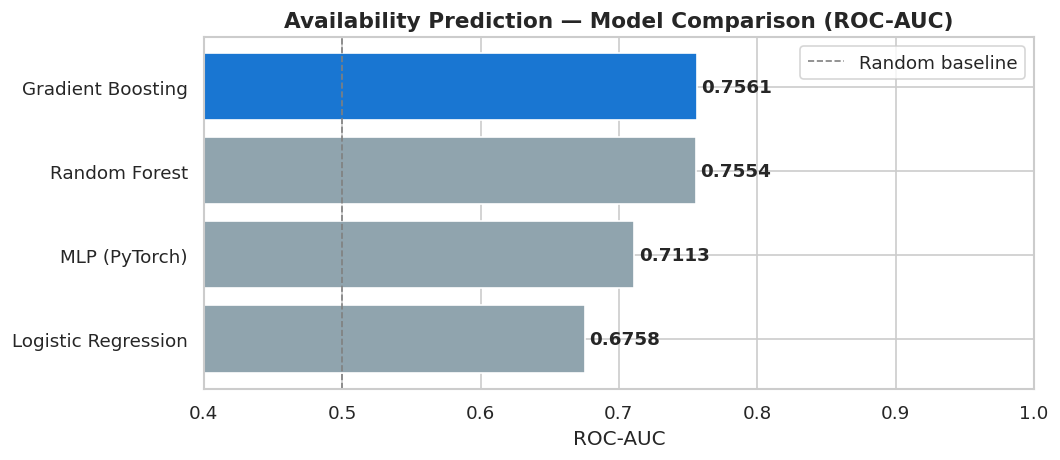


=== Final Model Ranking — Availability Prediction (by ROC-AUC) ===
  1. Gradient Boosting            0.7561
  2. Random Forest                0.7554
  3. MLP (PyTorch)                0.7113
  4. Logistic Regression          0.6758


In [21]:
comparison = {
    'Logistic Regression': results_avail['Logistic Regression']['ROC-AUC'],
    'Gradient Boosting':   results_avail['Gradient Boosting']['ROC-AUC'],
    'Random Forest':       results_avail['Random Forest']['ROC-AUC'],
    'MLP (PyTorch)':       val_aucs[-1],
}

comp_s = pd.Series(comparison).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 4))
colors_m = ['#1976D2' if i == 0 else '#90A4AE' for i in range(len(comp_s))]
bars = ax.barh(comp_s.index[::-1], comp_s.values[::-1], color=colors_m[::-1], edgecolor='white')
for bar, val in zip(bars, comp_s.values[::-1]):
    ax.text(bar.get_width() + 0.003, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=11, fontweight='bold')
ax.axvline(0.5, color='gray', linestyle='--', linewidth=1, label='Random baseline')
ax.set_xlabel('ROC-AUC')
ax.set_title('Availability Prediction — Model Comparison (ROC-AUC)', fontsize=13, fontweight='bold')
ax.set_xlim(0.4, 1.0)
ax.legend()
plt.tight_layout()
plt.show()

print('\n=== Final Model Ranking — Availability Prediction (by ROC-AUC) ===')
for rank, (name, score) in enumerate(comp_s.items(), 1):
    print(f'  {rank}. {name:<28} {score:.4f}')

_save_text_page(pdf, (
    'Final Model Ranking — Availability Prediction (by ROC-AUC):\n\n' +
    '\n'.join(
        f'  {rank}. {name:<28} {score:.4f}'
        for rank, (name, score) in enumerate(comp_s.items(), 1)
    ) +
    '\n\nNote: ROC-AUC > 0.5 = better than random guessing.\n'
    'Static config metadata (protocol + port) has limited but\n'
    'non-trivial predictive power for availability.'
), title='17. Final Model Ranking — Availability Prediction')

---
## 18. Security Feature Analysis

Explores new security fields: `proxy_detected` (65% of working configs), `has_ipv6` (16%), `ipv6_leak` (3%).

- **Security correlation heatmap** — which security flags co-occur?
- **Predicting proxy detection** from static metadata (before even connecting)
- **Cluster security profile** — do our K-Means clusters differ in security characteristics?

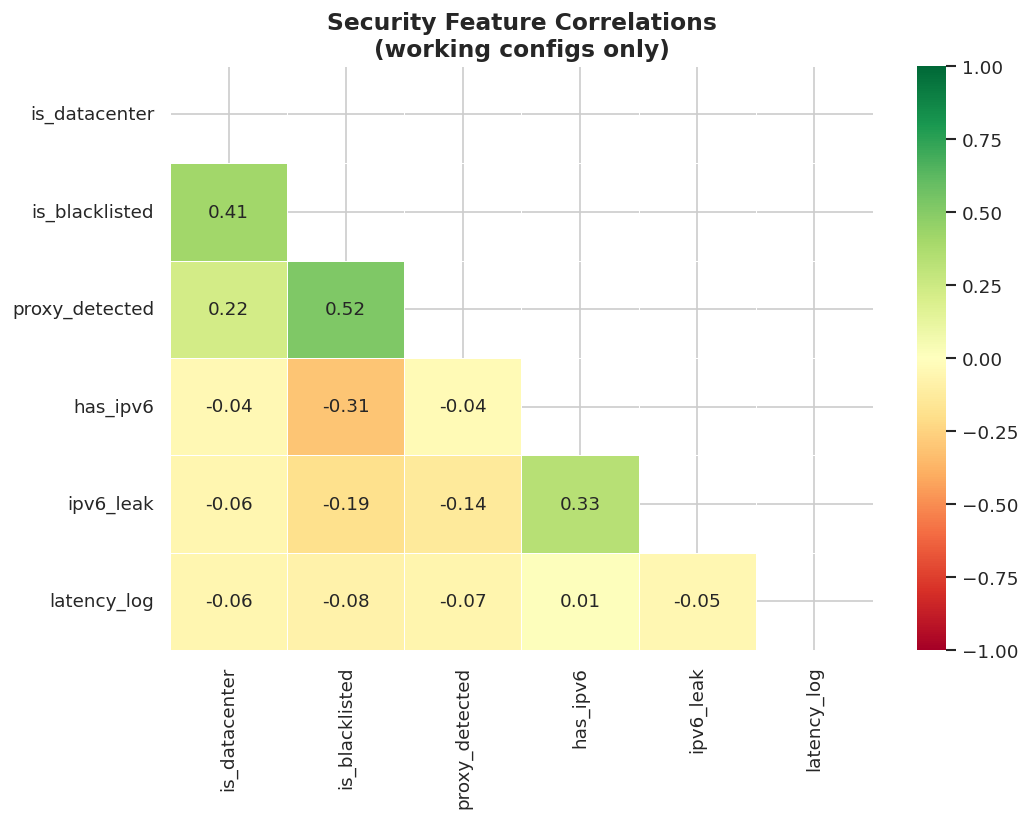

Logistic Regression        ROC-AUC=0.793±0.031
Random Forest              ROC-AUC=0.831±0.031
Gradient Boosting          ROC-AUC=0.833±0.023

High ROC-AUC here is expected: is_datacenter and is_blacklisted directly correlate
with proxy detection databases — they track the same hosting ranges.


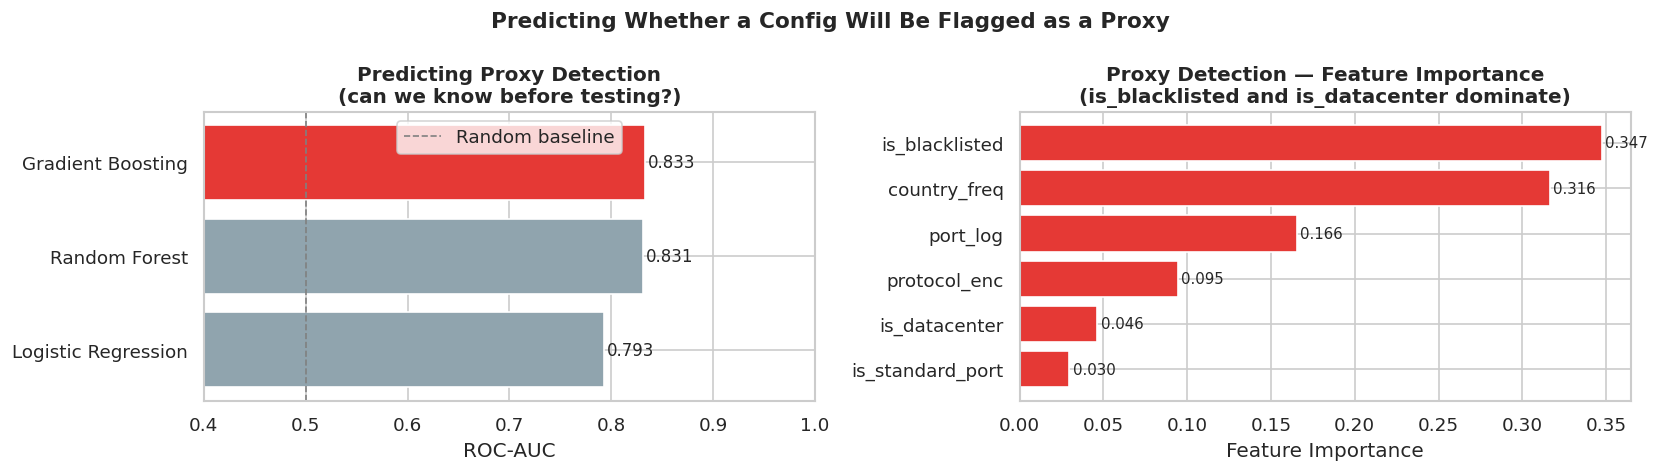

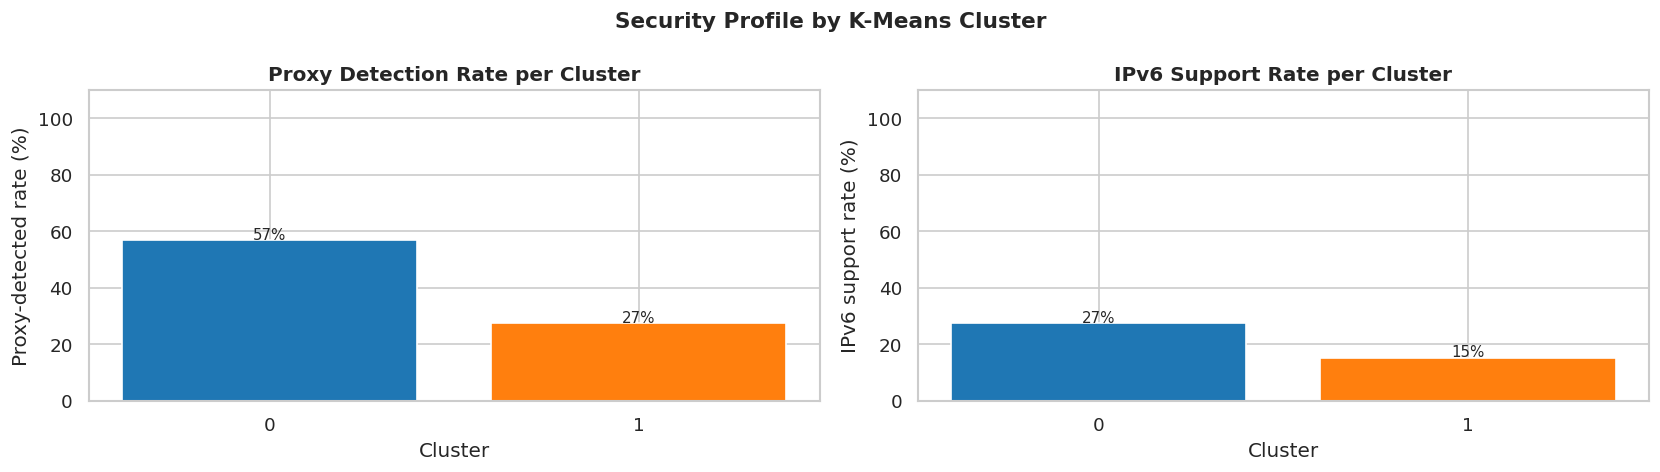

In [22]:
sec_cols = ['is_datacenter', 'is_blacklisted', 'proxy_detected', 'has_ipv6', 'ipv6_leak', 'latency_log']
sec_cols_avail = [c for c in sec_cols if c in working_df.columns]
sec_corr = working_df[sec_cols_avail].astype(float).corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(sec_corr, dtype=bool))
sns.heatmap(
    sec_corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
    center=0, vmin=-1, vmax=1, linewidths=0.5,
    ax=ax, annot_kws={'size': 11},
)
ax.set_title('Security Feature Correlations\n(working configs only)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

PD_FEATURES = ['protocol_enc', 'port_log', 'is_standard_port', 'country_freq', 'is_datacenter', 'is_blacklisted']
X_pd = working_df[PD_FEATURES].astype(float).values
y_pd = working_df['proxy_detected'].astype(int).values if 'proxy_detected' in working_df.columns else None

if y_pd is not None and y_pd.sum() >= 10 and (len(y_pd) - y_pd.sum()) >= 10:
    cv_pd = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    models_pd = {
        'Logistic Regression': LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
        'Random Forest':       RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42, n_jobs=-1),
        'Gradient Boosting':   GradientBoostingClassifier(n_estimators=150, random_state=42),
    }
    results_pd = {}
    for name, model in models_pd.items():
        pipe = Pipeline([('scaler', StandardScaler()), ('clf', model)])
        auc = cross_val_score(pipe, X_pd, y_pd, cv=cv_pd, scoring='roc_auc', n_jobs=-1)
        results_pd[name] = auc.mean()
        print(f'{name:<25}  ROC-AUC={auc.mean():.3f}±{auc.std():.3f}')

    print('\nHigh ROC-AUC here is expected: is_datacenter and is_blacklisted directly correlate')
    print('with proxy detection databases — they track the same hosting ranges.')

    rf_pd = RandomForestClassifier(n_estimators=300, class_weight='balanced', random_state=42, n_jobs=-1)
    rf_pd.fit(StandardScaler().fit_transform(X_pd), y_pd)
    imp_pd = pd.Series(rf_pd.feature_importances_, index=PD_FEATURES).sort_values(ascending=False)

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    ax = axes[0]
    res_pd_s = pd.Series(results_pd).sort_values(ascending=False)
    colors_pd = ['#E53935' if i == 0 else '#90A4AE' for i in range(len(res_pd_s))]
    bars = ax.barh(res_pd_s.index[::-1], res_pd_s.values[::-1], color=colors_pd[::-1], edgecolor='white')
    for bar, val in zip(bars, res_pd_s.values[::-1]):
        ax.text(bar.get_width() + 0.003, bar.get_y() + bar.get_height()/2,
                f'{val:.3f}', va='center', fontsize=10)
    ax.axvline(0.5, color='gray', linestyle='--', linewidth=1, label='Random baseline')
    ax.set_xlabel('ROC-AUC')
    ax.set_title('Predicting Proxy Detection\n(can we know before testing?)', fontsize=12, fontweight='bold')
    ax.set_xlim(0.4, 1.0)
    ax.legend()

    ax2 = axes[1]
    bars2 = ax2.barh(imp_pd.index[::-1], imp_pd.values[::-1], color='#E53935', edgecolor='white')
    for bar, val in zip(bars2, imp_pd.values[::-1]):
        ax2.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
                 f'{val:.3f}', va='center', fontsize=9)
    ax2.set_xlabel('Feature Importance')
    ax2.set_title('Proxy Detection — Feature Importance\n(is_blacklisted and is_datacenter dominate)', fontsize=12, fontweight='bold')

    plt.suptitle('Predicting Whether a Config Will Be Flagged as a Proxy', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

if 'cluster' in working_df.columns and 'proxy_detected' in working_df.columns:
    cluster_sec = working_df.groupby('cluster').agg(
        proxy_pct = ('proxy_detected', 'mean'),
        ipv6_pct  = ('has_ipv6', 'mean'),
    ).fillna(0) * 100

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    colors_c2 = sns.color_palette('tab10', K_BEST)

    ax = axes[0]
    bars = ax.bar(cluster_sec.index.astype(str), cluster_sec['proxy_pct'],
                  color=colors_c2, edgecolor='white')
    for bar, val in zip(bars, cluster_sec['proxy_pct']):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{val:.0f}%', ha='center', fontsize=9)
    ax.set_xlabel('Cluster')
    ax.set_ylabel('Proxy-detected rate (%)')
    ax.set_title('Proxy Detection Rate per Cluster', fontweight='bold')
    ax.set_ylim(0, 110)

    ax2 = axes[1]
    bars2 = ax2.bar(cluster_sec.index.astype(str), cluster_sec['ipv6_pct'],
                    color=colors_c2, edgecolor='white')
    for bar, val in zip(bars2, cluster_sec['ipv6_pct']):
        ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{val:.0f}%', ha='center', fontsize=9)
    ax2.set_xlabel('Cluster')
    ax2.set_ylabel('IPv6 support rate (%)')
    ax2.set_title('IPv6 Support Rate per Cluster', fontweight='bold')
    ax2.set_ylim(0, 110)

    plt.suptitle('Security Profile by K-Means Cluster', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

In [23]:
pdf.close()
print('Saved → ml_report.pdf')

Saved → ml_report.pdf
